In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
rfm = pd.read_csv("rfm_scored_table.csv")

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_segment
0,12347.0,7,1,711.79,3,1,5,9,315
1,12370.0,1,1,1590.82,5,1,5,11,515
2,12386.0,7,1,258.90,3,1,2,6,312
3,12395.0,11,1,346.10,2,1,3,6,213
4,12427.0,12,1,303.50,2,1,3,6,213


In [ ]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_segment
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,15539.954610,7.307801,1.435461,583.814879,3.136170,3.000000,3.000000,9.136170,346.617021
std,1711.621792,3.984381,1.765883,1402.487738,1.361466,1.415218,1.415218,2.909362,140.338605
min,12347.000000,1.000000,1.000000,11.600000,1.000000,1.000000,1.000000,3.000000,111.000000
25%,14107.000000,5.000000,1.000000,182.250000,2.000000,2.000000,2.000000,7.000000,231.000000
50%,15658.000000,7.000000,1.000000,311.810000,3.000000,3.000000,3.000000,9.000000,343.000000
75%,17068.000000,10.000000,1.000000,523.860000,4.000000,4.000000,4.000000,11.000000,453.000000
max,18269.000000,14.000000,34.000000,27834.610000,5.000000,5.000000,5.000000,15.000000,555.000000


In [ ]:
rfm_features = rfm[['Recency','Frequency','Monetary']]

In [ ]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency','Frequency','Monetary'])

In [ ]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

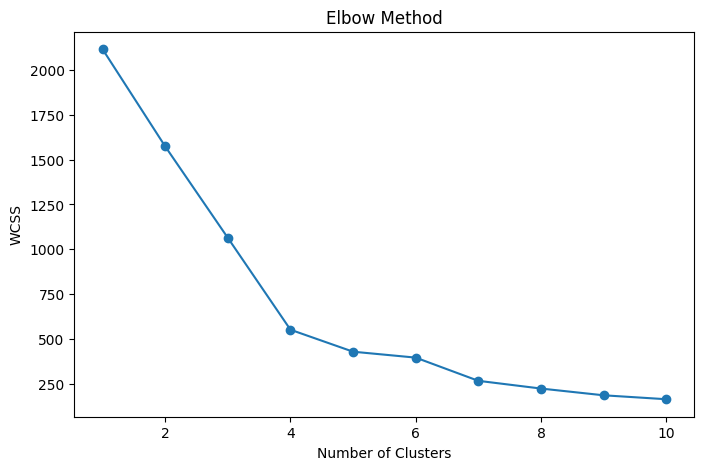

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [ ]:
rfm['Cluster'].value_counts()

,count
Cluster,
0,400
2,263
4,38
1,2
3,2


In [ ]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean',
    'CustomerID':'count'
}).rename(columns={'CustomerID':'Customers'})

cluster_summary

,Recency,Frequency,Monetary,Customers
Cluster,,,,
0,4.825000,1.305000,413.992950,400
1,6.500000,30.000000,4523.625000,2
2,11.570342,1.114068,345.255551,263
3,5.500000,7.500000,22589.695000,2
4,4.078947,3.210526,2656.933158,38


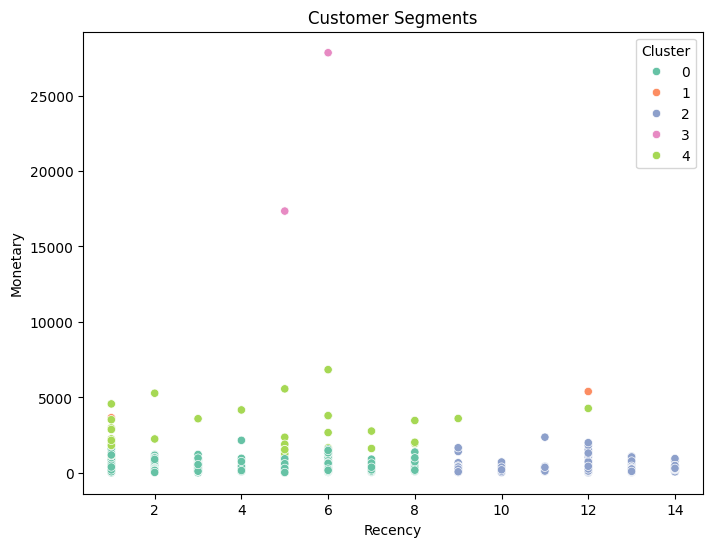

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set2')
plt.title("Customer Segments")
plt.show()

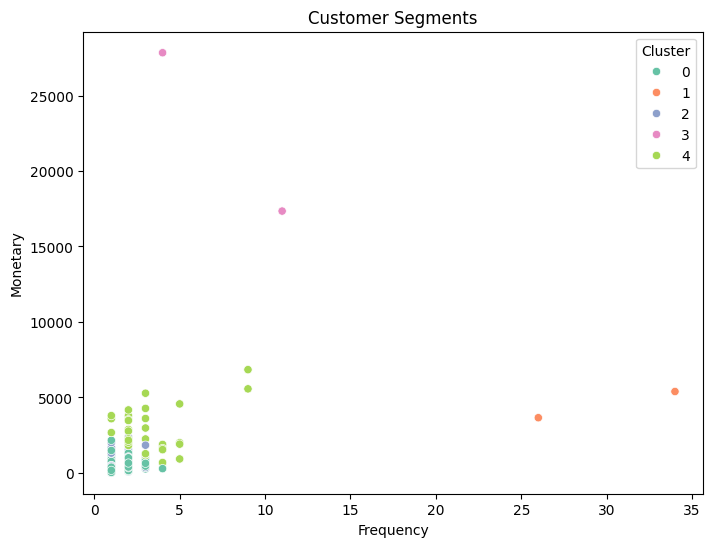

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set2')
plt.title("Customer Segments")
plt.show()

In [ ]:
segment_map = {
0: "Champions",
1: "Loyal Customers",
2: "Potential Loyalists",
3: "At Risk",
4: "Lost Customers"
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

In [ ]:
rfm[['CustomerID','Segment']].head()

,CustomerID,Segment
0,12347.0,Champions
1,12370.0,Champions
2,12386.0,Champions
3,12395.0,Potential Loyalists
4,12427.0,Potential Loyalists


In [ ]:
rfm['Segment'].value_counts()

,count
Segment,
Champions,400
Potential Loyalists,263
Lost Customers,38
Loyal Customers,2
At Risk,2


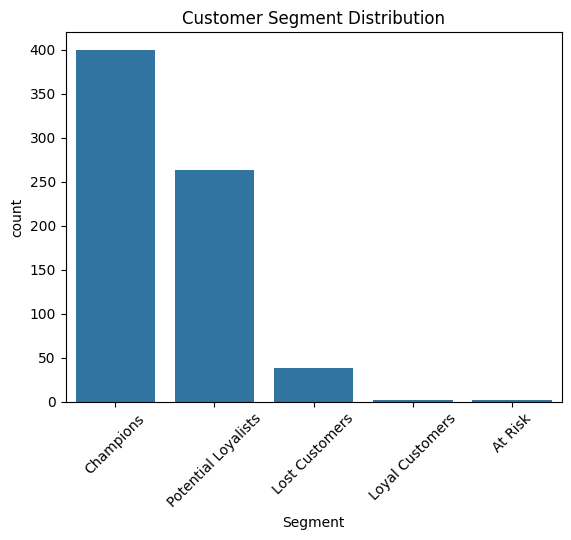

In [ ]:
sns.countplot(data=rfm, x='Segment')
plt.xticks(rotation=45)
plt.title("Customer Segment Distribution")
plt.show()

In [ ]:
rfm.to_csv("customer_segments.csv", index=False)